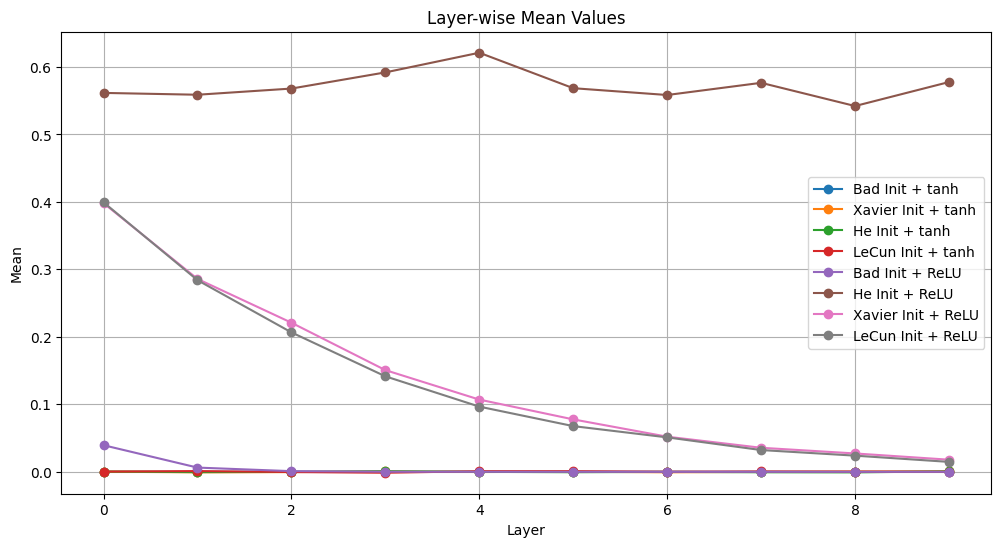

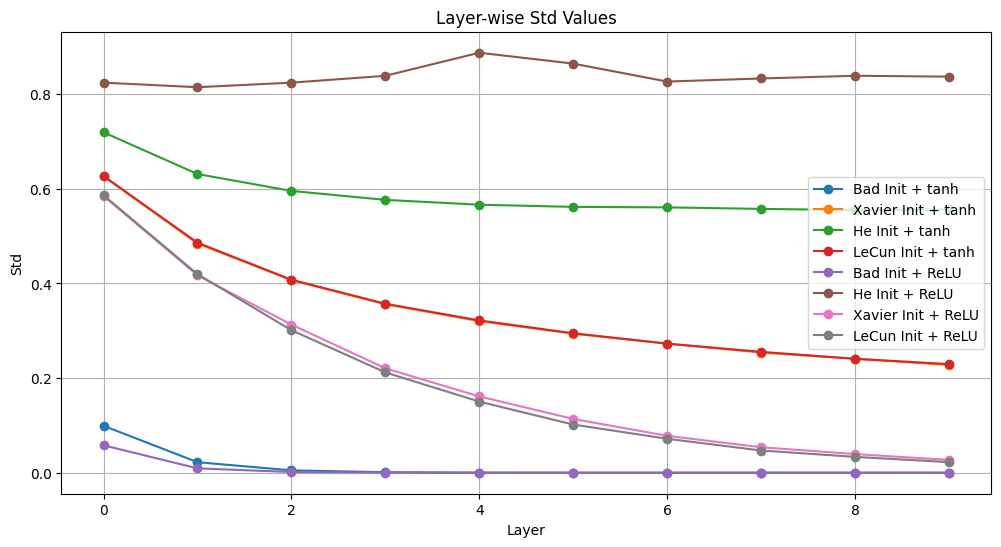

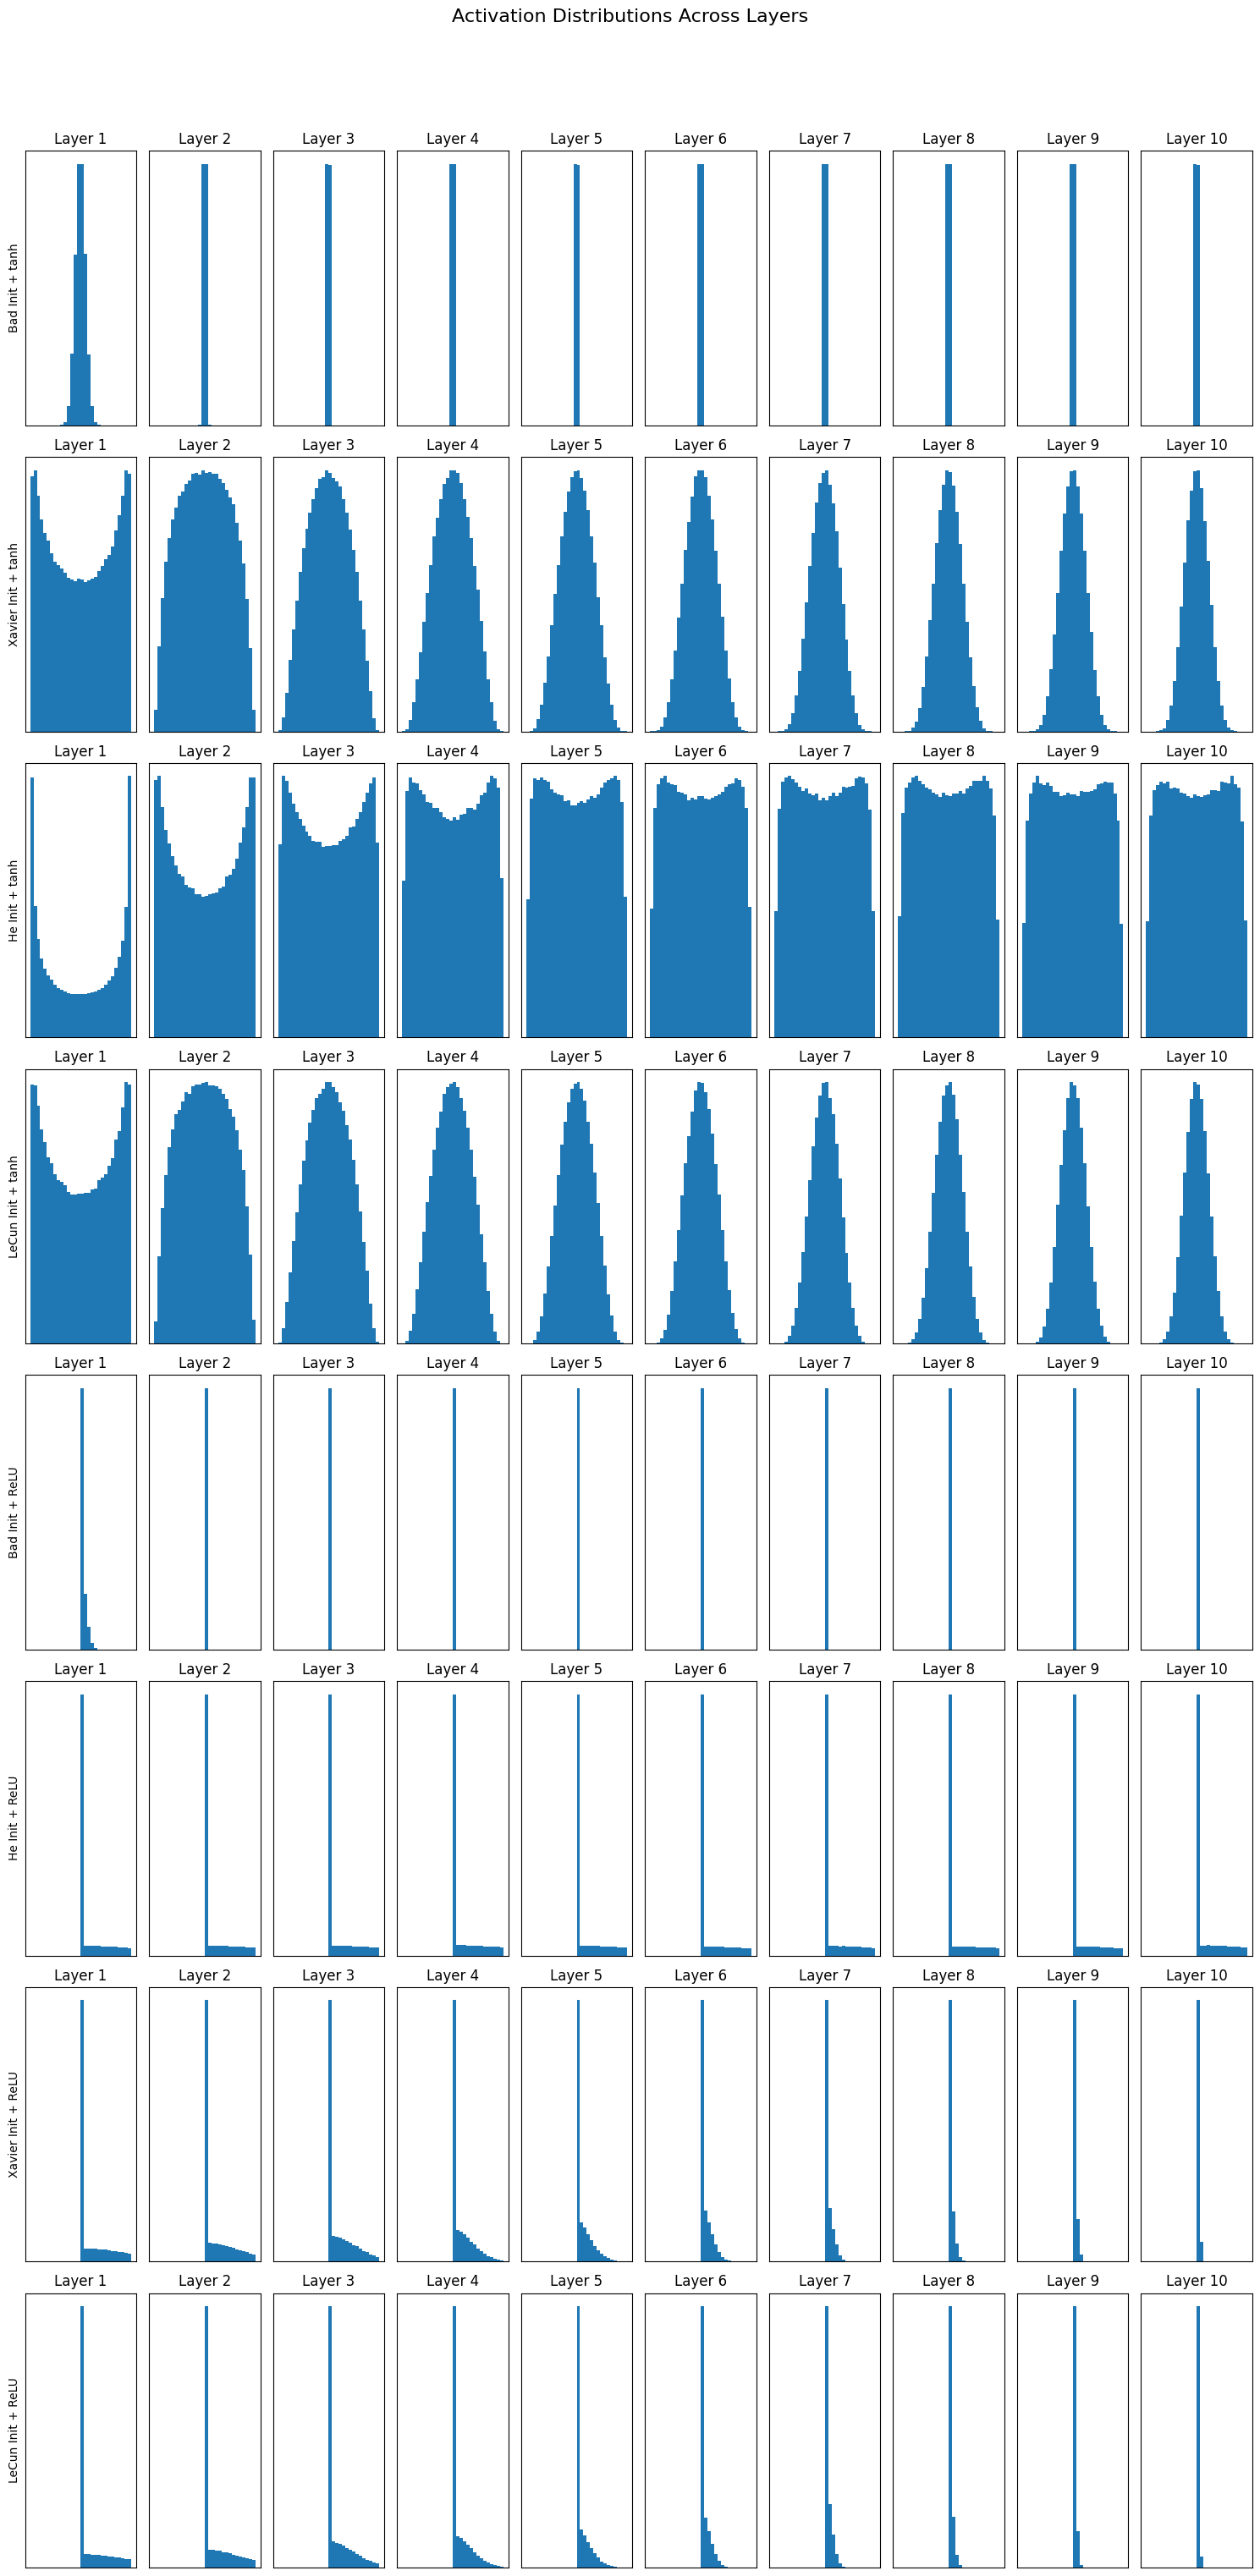

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Common settings
N, D = 1000, 100  # Number of samples (N) and input dimension (D)
hidden_layer_sizes = [500] * 10  # 10 hidden layers with 500 neurons each
np.random.seed(42)  # Set random seed for reproducibility

# Activation and Initialization functions
def relu(x): return np.maximum(0, x)  # ReLU activation function
def tanh(x): return np.tanh(x)  # Tanh activation function
def xavier_init(fan_in, fan_out): return np.random.randn(fan_in, fan_out) * np.sqrt(1. / fan_in)  # Xavier initialization
def he_init(fan_in, fan_out): return np.random.randn(fan_in, fan_out) * np.sqrt(2. / fan_in)  # He initialization
def lecun_init(fan_in, fan_out): return np.random.randn(fan_in, fan_out) * np.sqrt(1. / fan_in) # LeCun initialization
def bad_init(fan_in, fan_out): return np.random.randn(fan_in, fan_out) * 0.01  # Poor initialization with a small value

# Experiment settings with activation functions and initialization methods
experiments = [
    {'name': 'Bad Init + tanh', 'act': tanh, 'init': bad_init},
    {'name': 'Xavier Init + tanh', 'act': tanh, 'init': xavier_init},
    {'name': 'He Init + tanh', 'act': tanh, 'init': he_init},
    {'name': 'LeCun Init + tanh', 'act': tanh, 'init': lecun_init}, # Added LeCun + tanh
    {'name': 'Bad Init + ReLU', 'act': relu, 'init': bad_init},
    {'name': 'He Init + ReLU', 'act': relu, 'init': he_init},
    {'name': 'Xavier Init + ReLU', 'act': relu, 'init': xavier_init},
    {'name': 'LeCun Init + ReLU', 'act': relu, 'init': lecun_init}, # Added LeCun + ReLU
]

# Running all experiments
results = []  # To store the layer means, stds, and activations (Hs) for each experiment

for exp in experiments:
    X = np.random.randn(N, D)  # Initialize input data
    Hs = {}  # Dictionary to store activations of each layer

    # Forward pass through each layer
    for i in range(len(hidden_layer_sizes)):
        fan_in = X.shape[1]  # Input dimension (number of neurons in the previous layer)
        fan_out = hidden_layer_sizes[i]  # Output dimension (number of neurons in the current layer)
        W = exp['init'](fan_in, fan_out)  # Initialize weights using the selected method
        H = X @ W  # Perform matrix multiplication to get activations
        H = exp['act'](H)  # Apply the activation function
        Hs[i] = H  # Store the activation of this layer
        X = H  # Set the current output as the input for the next layer

    # Calculate mean and standard deviation of activations for each layer
    means = [np.mean(H) for H in Hs.values()]  # Mean of activations per layer
    stds = [np.std(H) for H in Hs.values()]  # Standard deviation of activations per layer

    # Store the results of the experiment
    results.append({'name': exp['name'], 'means': means, 'stds': stds, 'Hs': Hs})

# -----------------------------
# PLOTS
# -----------------------------

# 1. Mean and Std comparison across layers
# Plot mean values for each layer for all experiments
plt.figure(figsize=(12, 6))
for r in results:
    plt.plot(range(len(r['means'])), r['means'], marker='o', linestyle='-', label=r['name'])
plt.title('Layer-wise Mean Values')
plt.xlabel('Layer')
plt.ylabel('Mean')
plt.legend()
plt.grid(True)
plt.show()

# Plot standard deviation values for each layer for all experiments
plt.figure(figsize=(12, 6))
for r in results:
    plt.plot(range(len(r['stds'])), r['stds'], marker='o', linestyle='-', label=r['name'])
plt.title('Layer-wise Std Values')
plt.xlabel('Layer')
plt.ylabel('Std')
plt.legend()
plt.grid(True)
plt.show()

# 2. Histograms (Side-by-side for each experiment)
num_experiments = len(experiments)
plt.figure(figsize=(15, 4 * num_experiments))
plt.suptitle('Activation Distributions Across Layers', fontsize=16)
for idx, r in enumerate(results):
    for i, H in r['Hs'].items():
        plt.subplot(num_experiments, len(r['Hs']), idx * len(r['Hs']) + i + 1)
        plt.hist(H.ravel(), bins=30, range=(-1, 1))  # Plot histogram of activations for each layer
        if i == 0:
            plt.ylabel(r['name'])  # Label only the first subplot in each row
        plt.title(f"Layer {i+1}")  # Layer number title
        plt.xticks([])  # Remove x-axis ticks
        plt.yticks([])  # Remove y-axis ticks
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout for the main title
plt.show()